In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
excel_file = 'cleaned_dataset_ MohammadRezaei5.xlsx'
df = pd.read_excel(excel_file)

spending_75 = df['total_spending'].quantile(0.75)
spending_median = df['total_spending'].median()
recency_75 = df['last_purchase_days'].quantile(0.75)
recency_median = df['last_purchase_days'].median()

print(f"Total spending - Median: {spending_median:,.2f}, 75th percentile: {spending_75:,.2f}")
print(f"Last purchase days - Median: {recency_median}, 75th percentile: {recency_75}")

at_risk_df = df[(df['total_spending'] >= spending_median) & (df['last_purchase_days'] >= 180)].sort_values(by='total_spending', ascending=False)
print("\nAt-risk customers count:", len(at_risk_df))
print(at_risk_df[['customer_id', 'first_name', 'city', 'membership_tier', 'purchase_count', 'total_spending', 'last_purchase_days', 'satisfaction_score']])

Total spending - Median: 2,128.69, 75th percentile: 4,213.12
Last purchase days - Median: 203.0, 75th percentile: 273.75

At-risk customers count: 19
    customer_id first_name     city membership_tier  purchase_count  \
11         1012      Arash  Mashhad            Gold              27   
8          1009      Kimia    Karaj          Silver              34   
58         1059        Ali  Isfahan            Gold              31   
9          1010      Arash    Karaj          Silver              19   
49         1050       Reza  Mashhad          Bronze              30   
54         1055       Mina    Rasht          Bronze              19   
34         1035      Arash   Tabriz          Bronze              17   
52         1053       Sina   Tehran            Gold              18   
46         1047      Arash   Tabriz            Gold              23   
45         1046     Maryam   Tabriz             VIP              15   
31         1032       Neda  Isfahan          Silver              15  

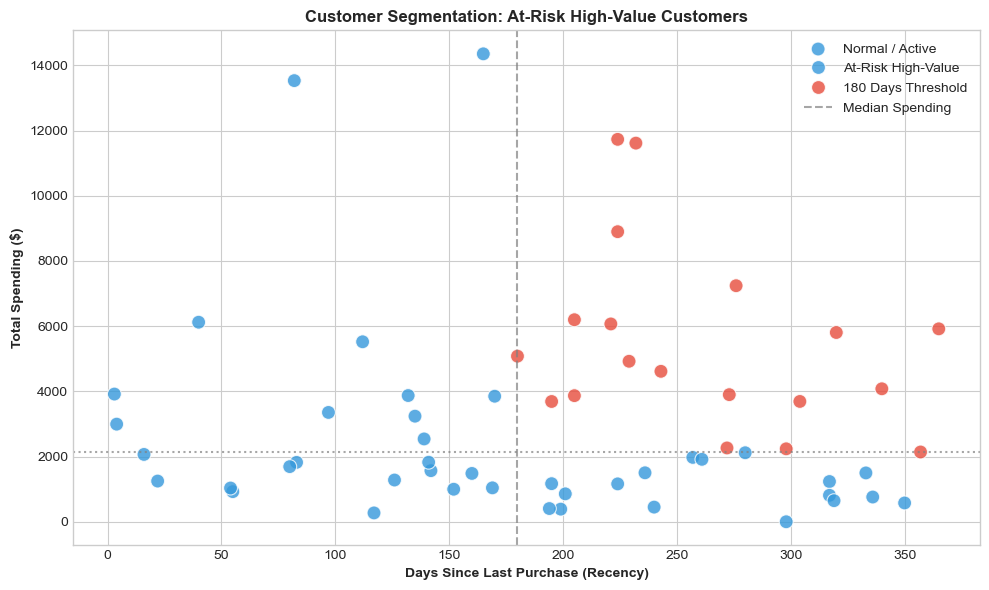

In [4]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=df, 
    x='last_purchase_days', 
    y='total_spending', 
    hue=(df['total_spending'] >= spending_median) & (df['last_purchase_days'] >= 180),
    palette={True: '#e74c3c', False: '#3498db'},
    s=100,
    alpha=0.8,
    ax=ax
)

ax.axvline(180, color='gray', linestyle='--', alpha=0.7, label='Recency Threshold (180 Days)')
ax.axhline(spending_median, color='gray', linestyle=':', alpha=0.7, label='Spending Threshold (Median = 2,128.69)')

ax.set_title('Customer Segmentation: At-Risk High-Value Customers', fontsize=12, fontweight='bold')
ax.set_xlabel('Days Since Last Purchase (Recency)', fontsize=10, fontweight='bold')
ax.set_ylabel('Total Spending ($)', fontsize=10, fontweight='bold')
ax.legend(['Normal / Active', 'At-Risk High-Value', '180 Days Threshold', 'Median Spending'])

plt.tight_layout()
plt.show()
plt.close()